# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.cluster import KMeans

pd.set_option("display.width", 160)
RANDOM_STATE = 42

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
DATA_PATH = ROOT / "data/raw/content_refresh_anonymized.csv"
if not DATA_PATH.exists():
    DATA_PATH = Path("content_refresh_anonymized.csv")  # Colab fallback

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} pages.")

# avg_position of 0 means "no data," not rank zero — treat it as missing.
df["avg_position_clean"] = df["avg_position"].replace(0, np.nan)
df["avg_position_clean"] = df["avg_position_clean"].fillna(df["avg_position_clean"].median())

Loaded 30,000 pages.


In [10]:
# Group pages into a few simple archetypes (same idea as Week 5/6, kept small
# here: 2 features, 1 fit, no search loop).

features = df[["impressions_90d", "days_since_last_update"]]
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df["archetype"] = kmeans.fit_predict(features)

print("Pages per archetype (median impressions / staleness):")
print(df.groupby("archetype")[["impressions_90d", "days_since_last_update"]].median().round(0))

Pages per archetype (median impressions / staleness):
           impressions_90d  days_since_last_update
archetype                                         
0                    569.0                    20.0
1                  98559.0                    26.0
2                  25981.0                    25.0
3                 328902.0                    22.0


In [11]:
# The rule, in plain words:
#   stale         = not updated in 31+ days
#   visible       = 500+ impressions in the last 90 days (worth a human's time)
#   underperform  = CTR below the median CTR of all visible pages
#
# Three actions, one reason code each:
#   refresh      -> stale, visible, and underperforming
#   investigate  -> visible and underperforming, but not stale (not a staleness problem)
#   monitor      -> everything else (too little traffic, or already performing fine)

stale = df["days_since_last_update"] >= 31
visible = df["impressions_90d"] >= 500
median_ctr = df.loc[visible, "ctr"].median()
underperforming = df["ctr"] < median_ctr

df["action"] = "monitor"
df.loc[visible & underperforming & stale, "action"] = "refresh"
df.loc[visible & underperforming & ~stale, "action"] = "investigate"

df["reason_code"] = "ok_or_low_traffic"
df.loc[df["action"] == "refresh", "reason_code"] = "stale_visible_underperforming"
df.loc[df["action"] == "investigate", "reason_code"] = "fresh_but_weak_ctr"

print(df["action"].value_counts())

action
monitor        21748
investigate     4722
refresh         3530
Name: count, dtype: int64


In [12]:
# Rank: refresh first, then investigate, then monitor. Inside each group,
# biggest pages first (impressions = the traffic upside a fix could recapture).

order = {"refresh": 0, "investigate": 1, "monitor": 2}
df["tier"] = df["action"].map(order)

ranked_queue = df.sort_values(["tier", "impressions_90d"], ascending=[True, False]).reset_index(drop=True)
ranked_queue["rank"] = ranked_queue.index + 1

cols = ["rank", "content_id", "client_id", "action", "reason_code", "archetype",
        "impressions_90d", "ctr", "days_since_last_update"]
ranked_queue = ranked_queue[cols]

print(f"Ranked queue: {len(ranked_queue):,} pages. Top 10:")
ranked_queue.head(10)

Ranked queue: 30,000 pages. Top 10:


,rank,content_id,client_id,action,reason_code,archetype,impressions_90d,ctr,days_since_last_update
0,1,content_5fe46e04994d,client_4e07408562,refresh,stale_visible_underperforming,3,517715,0.14,104
1,2,content_2cb567c3c89b,client_6208ef0f77,refresh,stale_visible_underperforming,3,497727,0.10,48
2,3,content_cb112fce36be,client_19581e27de,refresh,stale_visible_underperforming,3,309910,0.16,104
3,4,content_36ff89c8214e,client_19581e27de,refresh,stale_visible_underperforming,3,295097,0.05,104
4,5,content_b28d1efd668f,client_6208ef0f77,refresh,stale_visible_underperforming,3,286608,0.06,104
5,6,content_813e88069237,client_6208ef0f77,refresh,stale_visible_underperforming,1,233561,0.06,104
6,7,content_c8e9d6ab9013,client_19581e27de,refresh,stale_visible_underperforming,1,208678,0.00,104
7,8,content_b511d4bc4ad2,client_6208ef0f77,refresh,stale_visible_underperforming,1,205915,0.14,104
8,9,content_a7427266c305,client_19581e27de,refresh,stale_visible_underperforming,1,201111,0.11,104
9,10,content_33b4dceecad1,client_19581e27de,refresh,stale_visible_underperforming,1,181574,0.16,104


**Reading the queue:** `refresh` sits on top — stale pages still getting real traffic that
underperform other visible pages on CTR. `investigate` is separate on purpose: those pages
aren't stale, so a refresh may not be the right fix — something else needs a look first.

**archetype → action, roughly:** archetypes with high median staleness and real traffic feed
`refresh`; archetypes with low impressions mostly land in `monitor` regardless of staleness,
since there isn't enough traffic yet to justify the review time.

**Decay/refresh insight (from Week 4, holding here):** staleness is directionally associated
with lower CTR in this dataset — an **observed, directional** pattern, not proof that refreshing
a page *causes* CTR to recover, since no refresh was actually run and measured here. That's why
`stale` alone never triggers `refresh` — it also needs the separate, measured underperformance
signal.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [13]:
print("Intended use:")
print("- Who: a content/SEO editor doing weekly triage across one client's pages.")
print("- What for: deciding which pages to open and look at first. A sorted worklist,")
print("  not an autopilot — every row still needs the human review in Section 3.")
print("- Scope: review one client at a time. Rank isn't meaningful across two different clients.")
print("- Time window: one 90-day snapshot. It says nothing about before or after it.")

print("\nLimits:")
print("- Cross-sectional, not an experiment: the underperform flag compares pages at one")
print("  point in time, not before vs. after a real refresh. Decision-support language only")
print("  ('worth reviewing first'), never causal ('refreshing this will help').")
print("- Archetypes are descriptive groupings, not a validated predictive label.")
print("- The model never reads the page. A low-CTR page could be a real problem, or a")
print("  branded/navigational query where low CTR is normal.")

Intended use:
- Who: a content/SEO editor doing weekly triage across one client's pages.
- What for: deciding which pages to open and look at first. A sorted worklist,
  not an autopilot — every row still needs the human review in Section 3.
- Scope: review one client at a time. Rank isn't meaningful across two different clients.
- Time window: one 90-day snapshot. It says nothing about before or after it.

Limits:
- Cross-sectional, not an experiment: the underperform flag compares pages at one
  point in time, not before vs. after a real refresh. Decision-support language only
  ('worth reviewing first'), never causal ('refreshing this will help').
- Archetypes are descriptive groupings, not a validated predictive label.
- The model never reads the page. A low-CTR page could be a real problem, or a
  branded/navigational query where low CTR is normal.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [14]:
print("Before acting on any row, a human must:")
print("1. Open the page and read it — a reason code is a hypothesis, not a diagnosis.")
print("2. Check if the query is branded/navigational (low CTR there is often normal).")
print("3. Check for a recent ranking shake-up before assuming decay.")
print("4. Confirm the client is one you're staffed to review this week.")

print("\nNever automate:")
print("- No auto-publish. Every action is a suggested next look, never an executed change.")
print("- No automatic budget or headcount decisions from rank alone.")
print("- No client-facing reporting using raw reason codes — they're internal triage labels.")
print("- No cross-client comparisons in front of a client.")

Before acting on any row, a human must:
1. Open the page and read it — a reason code is a hypothesis, not a diagnosis.
2. Check if the query is branded/navigational (low CTR there is often normal).
3. Check for a recent ranking shake-up before assuming decay.
4. Confirm the client is one you're staffed to review this week.

Never automate:
- No auto-publish. Every action is a suggested next look, never an executed change.
- No automatic budget or headcount decisions from rank alone.
- No client-facing reporting using raw reason codes — they're internal triage labels.
- No cross-client comparisons in front of a client.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [15]:
print("Signal 1: median CTR moves a lot -> shifts >20% from this run's value.")
print("  Action: recompute it fresh each run (already automatic), note the shift.")

print("\nSignal 2: refresh backlog grows -> volume outpaces editor capacity for 2+ weeks.")
print("  Action: raise the visibility threshold or add a client filter.")

print("\nSignal 3: archetype sizes shift a lot -> any group's share moves >30% vs. this run.")
print("  Action: re-check what each archetype actually looks like before trusting it.")

print("\nCadence: monthly re-run, no automated retraining — any trigger above routes to")
print("a person re-running this notebook, not an automatic job.")

Signal 1: median CTR moves a lot -> shifts >20% from this run's value.
  Action: recompute it fresh each run (already automatic), note the shift.

Signal 2: refresh backlog grows -> volume outpaces editor capacity for 2+ weeks.
  Action: raise the visibility threshold or add a client filter.

Signal 3: archetype sizes shift a lot -> any group's share moves >30% vs. this run.
  Action: re-check what each archetype actually looks like before trusting it.

Cadence: monthly re-run, no automated retraining — any trigger above routes to
a person re-running this notebook, not an automatic job.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote content_action_playbook_queue.csv
Wrote action_playbook_summary.json


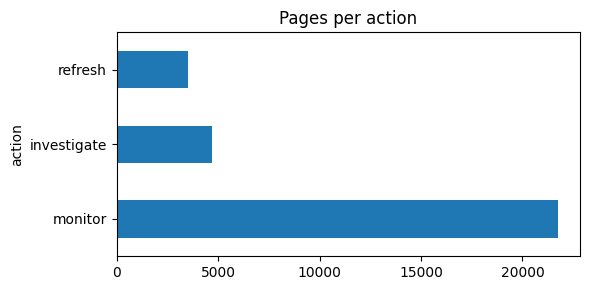

Wrote w07_action_counts.png


In [16]:
import json
import matplotlib.pyplot as plt

output_dir = ROOT / "work/outputs"
output_dir.mkdir(parents=True, exist_ok=True)
figures_dir = ROOT / "work/figures"
figures_dir.mkdir(parents=True, exist_ok=True)

ranked_queue.to_csv(output_dir / "content_action_playbook_queue.csv", index=False)
print("Wrote content_action_playbook_queue.csv")

receipt = {
    "lane": "structured_content_archetype_clustering",
    "k_used": 4,
    "action_counts": df["action"].value_counts().to_dict(),
    "decay_refresh_insight": (
        "Weighted CTR is directionally lower for staler content in this dataset "
        "(Week-4 signal check); observed and directional, not causal."
    ),
}
(output_dir / "action_playbook_summary.json").write_text(json.dumps(receipt, indent=2) + "\n")
print("Wrote action_playbook_summary.json")

df["action"].value_counts().plot(kind="barh", figsize=(6, 3), title="Pages per action")
plt.tight_layout()
plt.savefig(figures_dir / "w07_action_counts.png", dpi=150)
plt.show()
print("Wrote w07_action_counts.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

# ML-12 Showcase: 5-minute demo outline

**0:00-0:40 - Question.** In this public-safe FlyRank case study, I asked: when thousands of published pages compete for limited editorial time, which pages should a human open first? The goal is decision support for weekly triage, not a promise to predict traffic or automatically change content.

**0:40-1:40 - Method.** I analyzed 30,000 pseudonymized pages across 32 client sites from one 90-day snapshot. I held out 20% of clients entirely, then fit a deliberately simple four-cluster K-Means model using 90-day impressions and days since last update. I excluded identifiers, label-derived trend fields, and existing FlyRank product flags to avoid leakage and circular reasoning.

**1:40-2:40 - One chart.** Show `work/figures/w07_action_counts.png`. It makes the operational output concrete: each page receives an explainable `refresh`, `investigate`, or `monitor` recommendation, so an editor sees a manageable review order rather than a black-box score.

**2:40-3:40 - One honest result.** On held-out clients, the four learned groups had a silhouette score of 0.84 versus -0.13 for the hand-written tier baseline. The important caveat is that the clusters were separated mainly by traffic magnitude, not staleness: this is a useful traffic-segmentation lens, not proof that the model discovered complete content-health archetypes.

**3:40-5:00 - Recommendation.** Use the queue as a human-review starting point: open high-visibility, stale, low-CTR pages in `refresh` first, investigate visible low-CTR pages that are not stale, and monitor the rest. Before acting, an editor should check for branded or navigational intent, recent ranking changes, and tracking issues. No recommendation is auto-published, and no causal benefit from a refresh is claimed.

## Shareable cuts

### Social post
I built a public-safe content-triage case study from 30,000 pseudonymized FlyRank pages. I used a grouped-by-client holdout and a deliberately simple K-Means model to turn traffic and freshness signals into an explainable `refresh` / `investigate` / `monitor` queue. The key lesson: the groups were driven mostly by traffic magnitude, so the result is a practical editorial-review lens - not a claim that refreshing content causes growth.

### Employer-facing summary
I built an explainable editorial-triage workflow that clusters content pages and produces a ranked, reason-coded review queue. I used 30,000 pseudonymized pages across 32 client sites, with a grouped-by-client holdout to prevent client-pattern leakage. The analysis showed clearer held-out grouping than a hand-written tier baseline, while also showing that traffic scale - more than staleness - drove the clusters, which shaped a cautious human-in-the-loop recommendation.